In [1]:
from probjax.distributions import *
from probjax.distributions.transformed_distribution import TransformedDistribution
import jax
import jax.numpy as jnp
from probjax.core.custom_primitives.random_variable import rv

from jax.api_util import flatten_fun_nokwargs


import matplotlib.pyplot as plt
key = jax.random.PRNGKey(0)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# Distributions

Just testing some of the distributions

## Continous Distributions

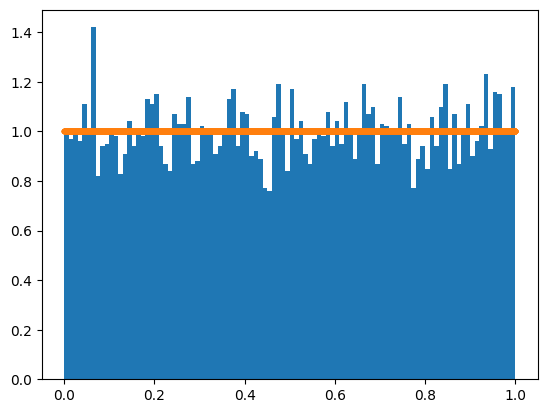

In [2]:
p = Uniform(low=0., high=1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


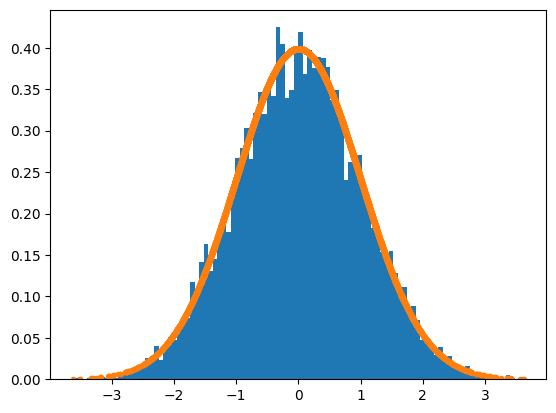

In [3]:
p = Normal(0.,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


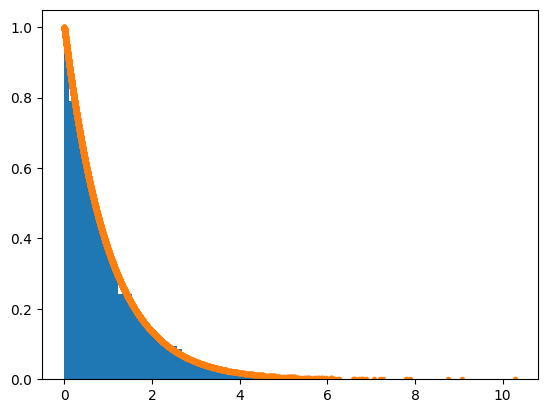

In [4]:
p = Gamma(1.,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


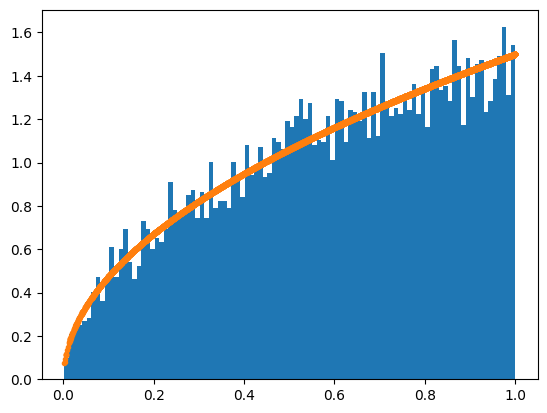

In [5]:
p = Beta(1.5,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


Array(True, dtype=bool)

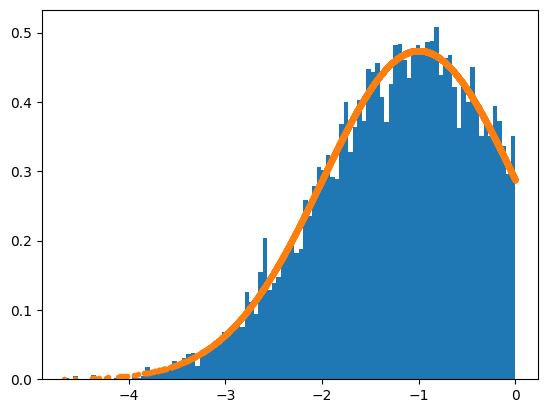

In [6]:
p = TruncatedNormal(-1.,1., low=-100., high=1.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
jnp.isfinite(log_prob).all()

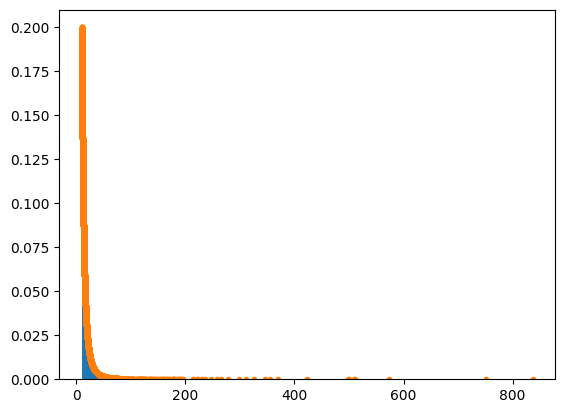

In [7]:
p = Pareto(2.,10.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

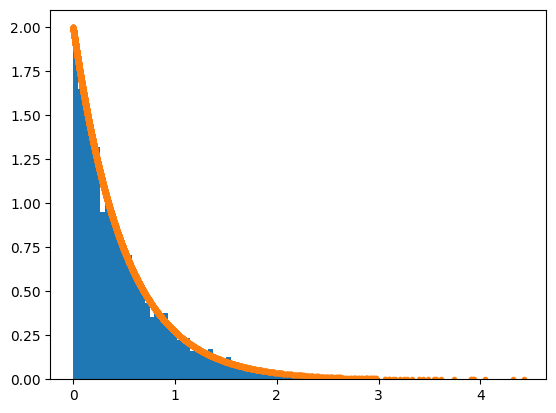

In [8]:
p = Exp(2.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

Array(-3.936, dtype=float32)

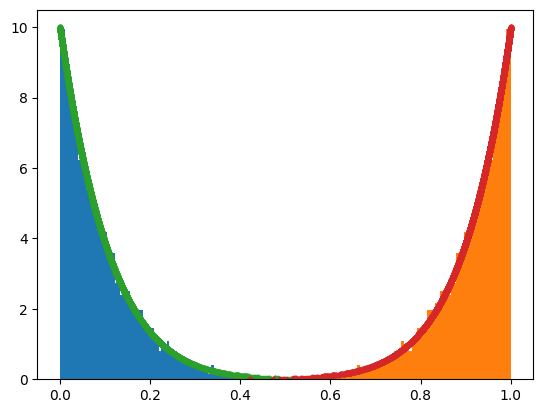

In [9]:
p = Dirichlet(jnp.array([1.,10.]))
samples = p.sample(key, (10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

p.log_prob(jnp.array([0.5,0.5]))


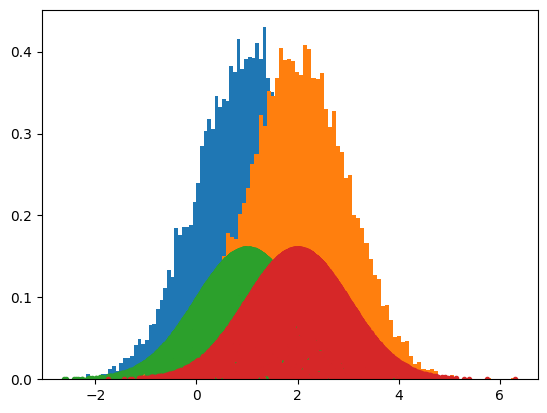

In [10]:
p = MultivariateNormal(jnp.array([1.,2.]), jnp.eye(2))
samples = p.sample(key, (10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


## Mixture

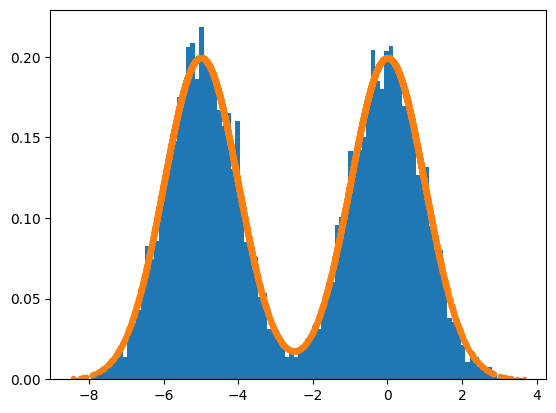

In [11]:
p1 = Normal(0.,1.)
p2 = Normal(-5.,1.)

p = Mixture(jnp.array([0.5,0.5]), [p1,p2])
samples = p.sample(key, (10000,))
_ = plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

## Discrete

(0.0, 1.0)

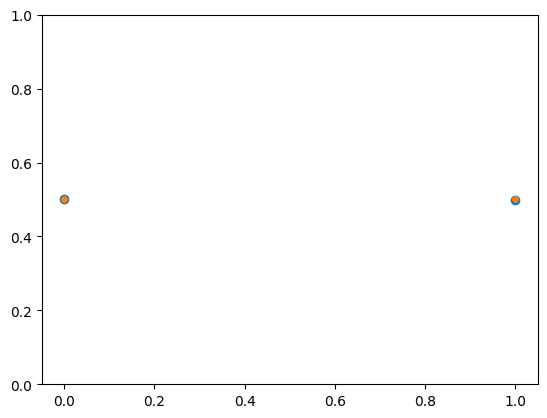

In [12]:
p = Bernoulli(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

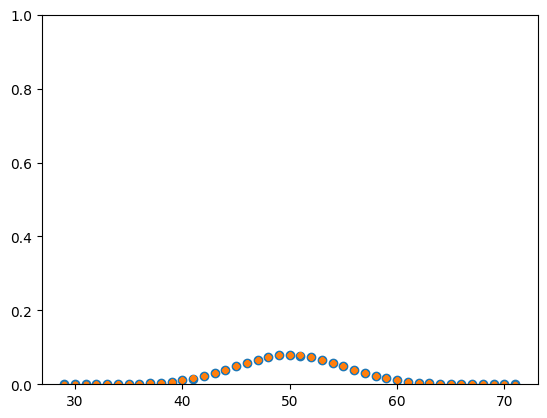

In [13]:
p = Binomial(100, jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

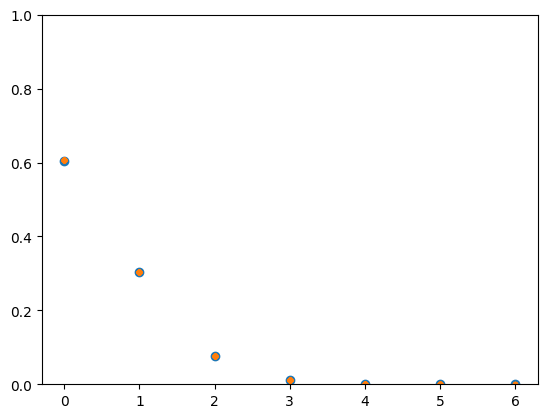

In [14]:
p = Poisson(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

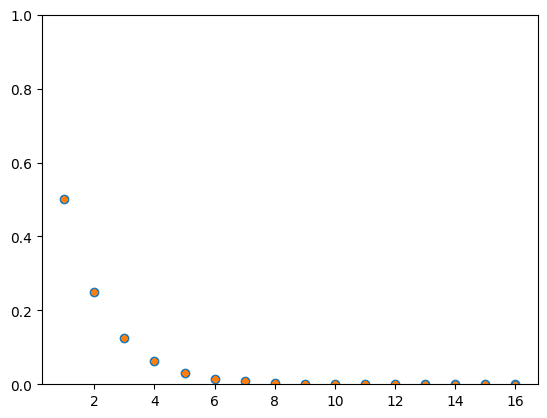

In [15]:
p = Geometric(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

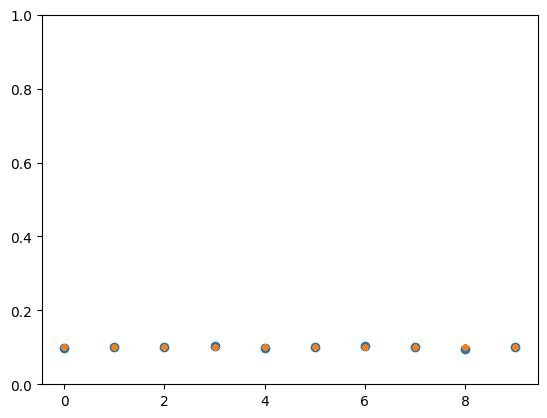

In [16]:
p = Categorical(jnp.ones((10)))
samples = p.sample(key, (10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

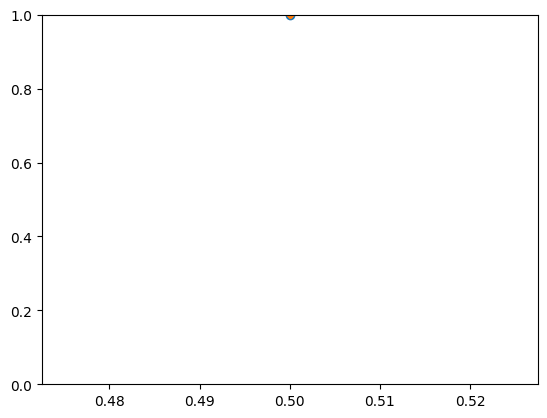

In [17]:
p = Dirac(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

In [18]:
log_prob.shape

(100000, 1)

(0.0, 1.0)

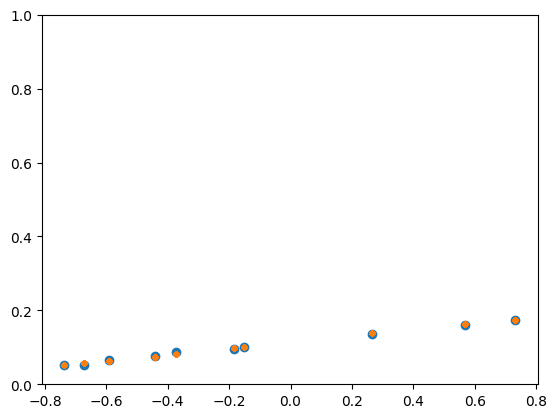

In [19]:
p = Empirical(jax.random.normal(key, (10,1)), probs=jax.random.uniform(key, (10,))/jax.random.uniform(key, (10,)).sum())
samples = p.sample(key, (10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".", color="C1")
plt.ylim(0,1)

# SDEs

In [22]:
from probjax.distributions.sde import *

In [27]:
# A = jnp.array([[0.,1.],[-1.,0.]])
# B = jnp.eye(2)*0.1

# ts = jnp.linspace(0., 5., 1000)
# p0 = Independent(Normal(jnp.zeros((2,)), jnp.ones((2,))), 1)
# sde = LinearTimeInvariantSDE(A, B,p0 )

# xs = sde.sample(key, ts,(5,))
# mean = sde.mean(ts)
# std = sde.stddev(ts)
# _ = plt.plot(ts,xs[:, :, 0].T, "C0")
# _ = plt.plot(ts, xs[..., 1].T, "C1")
# _ = plt.plot(ts, mean[..., 0], "C0--")
# _ = plt.plot(ts, mean[..., 1], "C1--")


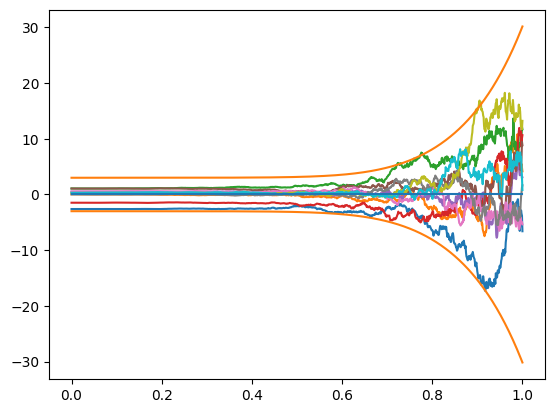

In [28]:
p0 = Normal(jnp.zeros(1), jnp.ones(1))
ts = jnp.linspace(0., 1., 1000)
sde = VESDE(p0)
mean = sde.mean(ts)
variance = sde.variance(ts)

xs = sde.sample(key, ts,(10,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, mean)
_ = plt.plot(ts, mean + 3*jnp.sqrt(variance), color="C1")
_ = plt.plot(ts, mean - 3*jnp.sqrt(variance), color="C1")

In [39]:
sde.mean(jax.random.uniform(key, (10,1)), x0 = jnp.zeros((10,))).shape

(1, 10, 10)

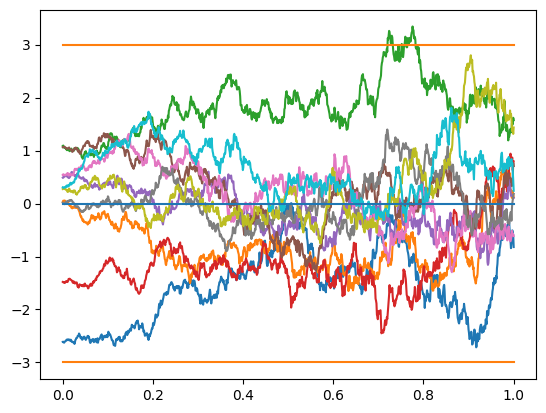

In [24]:
p0 = Normal(jnp.zeros(1), jnp.ones(1))
ts = jnp.linspace(0., 1., 1000)
sde = VPSDE(p0)
mean = sde.mean(ts)
variance = sde.variance(ts)

xs = sde.sample(key, ts,(10,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, mean)
_ = plt.plot(ts, mean + 3*jnp.sqrt(variance), color="C1")
_ = plt.plot(ts, mean - 3*jnp.sqrt(variance), color="C1")

# Transformed Distributon

(0.0, 1.0)

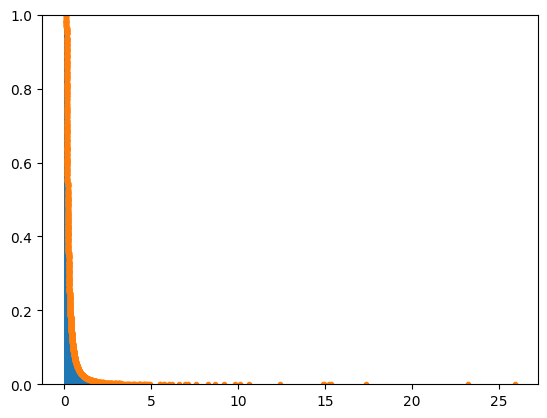

In [25]:
p0 = Normal(0.,1.)
p = TransformedDistribution(p0, lambda x: jnp.exp(x -2)**2)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

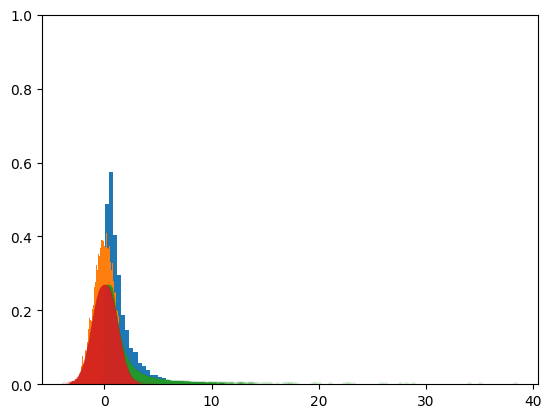

In [26]:
p0 = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)

def t(x):
    x = x.at[...,0].set(jnp.exp(x[...,0]))
    return x

p = TransformedDistribution(p0, t)

samples = p.sample(key, (10000,))
_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".", alpha=0.1)
plt.ylim(0,1)

# Mixture

## Divergences

### KL divergence

In [27]:
from probjax.distributions.divergences import kl_divergence

p0 = Normal(0.,1.)
p1 = Normal(0.,2.)
dist = kl_divergence(p0,p1)

dist

Array(0.318, dtype=float32, weak_type=True)